### Analysis of learned plasticity rule that organizes integrating network
Networks initialized with structured input weights, but weights in 'ellipsoid body' are random but fully connected.

In [8]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib.pyplot as plt
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted

plt.rcParams['font.family'] = 'Helvetica'

DATA_PATHS = [
    'test_int_short_715323_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_FRACI_0.0_SEED_2000_2025-07-15_16:46:24.093388',
    'test_int_short_715325_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_FRACI_0.0_SEED_2000_2025-07-15_16:42:05.562813',
    # 'test_int_long_corrected_329528_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_FRACI_0.0_SEED_2000_2025-07-15_15:24:45.686601',
    # 'test_int_long_corrected_338358_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_FRACI_0.0_SEED_2000_2025-07-15_15:31:06.064586',
    # 'test_int_long_corrected_363894_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_FRACI_0.0_SEED_2000_2025-07-15_15:37:29.832029',
    # 'test_int_long_corrected_715323_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_FRACI_0.0_SEED_2000_2025-07-15_15:18:29.654891',
    # 'test_int_long_corrected_715325_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_FRACI_0.0_SEED_2000_2025-07-15_15:12:12.848545',
]

DATA_PATHS = [ './sims_out/' + d for d in DATA_PATHS]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
def load_numpy(data_path):
    file_names = glob.glob(data_path)
    data = []
    for file_name in sorted(file_names):
        data_for_file = np.load(file_name)
        data.append(data_for_file)
    return data

def make_path_if_not_exists(path_str):
    Path(path_str).mkdir(parents=True, exist_ok=True)

### Analysis of neural activity

In [10]:
def load_r_and_int_values(rule_path, net_path):
    all_r = load_numpy(os.path.join(rule_path, 'activities', net_path))
    all_r = np.stack(all_r[-100:])
    last_100_r = all_r[-100:, 200:, :15]
    last_100_r = np.transpose(last_100_r, [2, 0, 1])

    all_int_values_raw = load_numpy(os.path.join(rule_path, 'integrated_values', net_path))
    all_int_values = np.stack(all_int_values_raw[-100:])

    print(last_100_r.shape)
    print(all_int_values.shape)
    

    return last_100_r, all_int_values

Do PCA on last 50 trials, 15 units in ellipsoid body.

In [4]:
def fit_pca(last_100_r):
    flattened_data = last_100_r.reshape(last_100_r.shape[0], last_100_r.shape[1] * last_100_r.shape[2], order='C')
    pca = PCA()
    pc_activities = pca.fit_transform(flattened_data.T)
    pc_activities = pc_activities.T.reshape(last_100_r.shape, order='C')

    return pc_activities, pca

Learned structure leads to low dimensional activity.

In [ ]:
scale = 0.8
fig, axs = plt.subplots(1, 1, figsize=(6 * scale, 4 * scale))

explained_variance_ratios = pca.explained_variance_ratio_
axs.bar(np.arange(explained_variance_ratios.shape[0]), explained_variance_ratios)
axs.set_xlim(-0.75, 10)
axs.set_ylabel('Variance explained')
axs.set_xlabel('PC')
format_plot(axs)

Retrieve target integrated sums. Keep only the last 100 trials.

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


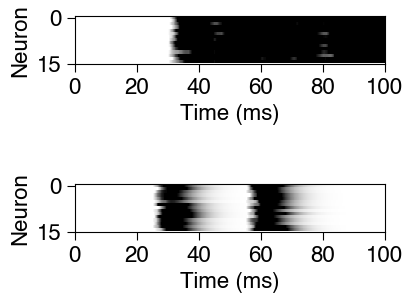

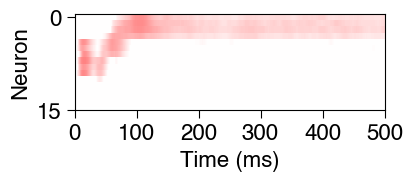

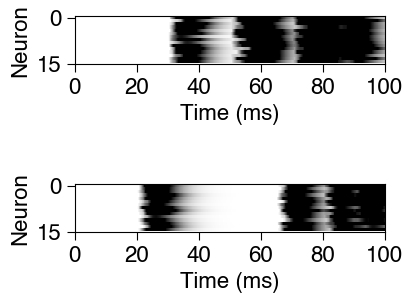

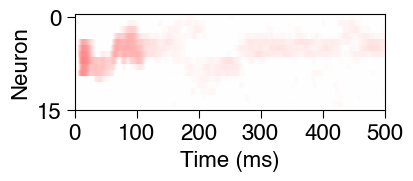

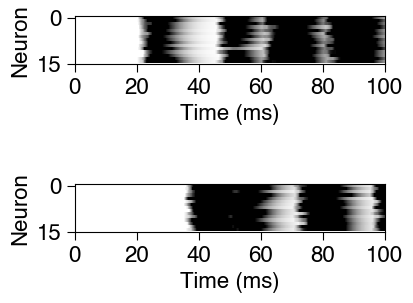

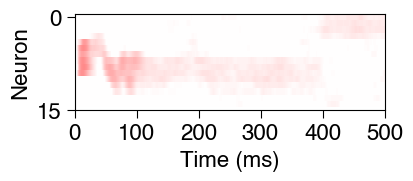

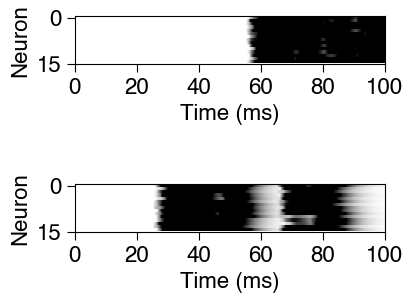

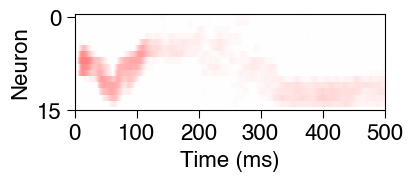

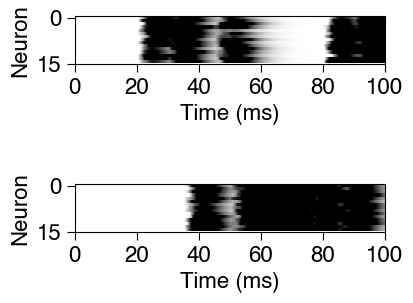

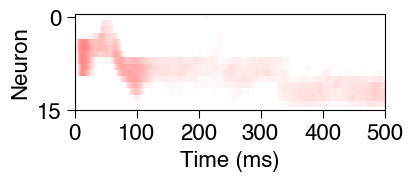

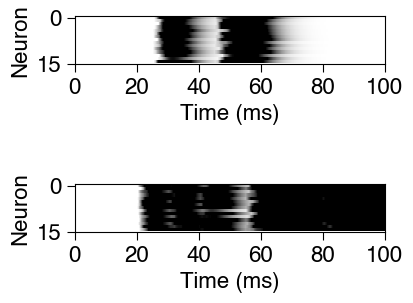

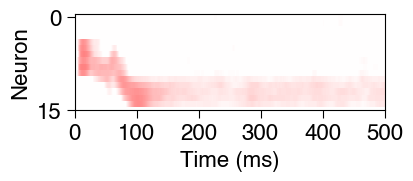

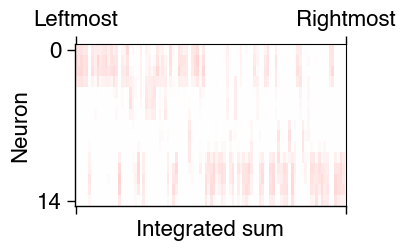

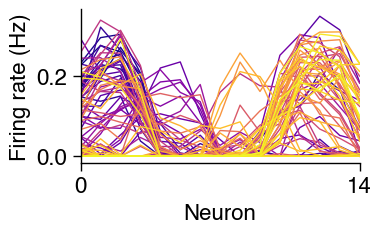

In [58]:
scale = 4

inputs_raw = load_numpy(os.path.join(DATA_PATHS[0], 'inputs/net_001_*.npy'))
inputs = np.concatenate([np.zeros((100, 200, 30)), np.stack(inputs_raw[-100:])], axis=1)

ending_states = np.empty((last_100_r.shape[0], last_100_r.shape[1]))

for i, j in enumerate(np.argsort(all_int_values[:, -1])):
    
    if i % 20 == 0 or i == len(all_int_values[:, -1]) - 1:
        fig, axs = plt.subplots(2, 1, figsize=(1 * scale, 1 * scale))
        axs[0].matshow(inputs[j, :, :15].T, cmap='binary', vmin=0, vmax=5, aspect=10)
        axs[1].matshow(inputs[j, :, 15:].T, cmap='binary', vmin=0, vmax=5, aspect=10)
        for k in range(2):
            axs[k].set_xlabel('Time (ms)', fontsize=16)
            axs[k].set_ylabel('Neuron', fontsize=16)
            axs[k].set_xticks(np.arange(0, 1001, 200), (np.arange(0, 1001, 200) / 10).astype(int))
            axs[k].set_yticks([0, 15])
            axs[k].tick_params(axis='x', bottom=True, top=False, labelbottom=True, labeltop=False)
            axs[k].xaxis.set_label_position('bottom')
            axs[k].tick_params(axis='both', length=6, labelsize=16)

        fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
        axs.matshow(last_100_r[:, j, :], cmap='bwr', vmin=-2, vmax=2, aspect=100)
        axs.set_xlabel('Time (ms)', fontsize=16)
        axs.set_ylabel('Neuron', fontsize=16)
        axs.set_xticks(np.arange(0, 5001, 1000), (np.arange(0, 5001, 1000) / 10).astype(int))
        axs.set_yticks([0, 15])
        axs.tick_params(axis='x', bottom=True, top=False, labelbottom=True, labeltop=False)
        axs.xaxis.set_label_position('bottom')
        axs.tick_params(axis='both', length=6, labelsize=16)
    
for i, j in enumerate(np.argsort(all_int_values[:, -250])):
    ending_states[:, i] = last_100_r[:, j, -250]
    
#     fig.savefig(os.path.join(img_path, f'act_{zero_pad(run, 4)}_t_{zero_pad(timestep, 4)}.png'))
#     plt.close()

scale = 3.5
fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
axs.matshow(ending_states, cmap='bwr', vmin=-2, vmax=2, aspect=4)

format_plot(axs, rightspine=True, topspine=True)

axs.set_xlabel('Integrated sum', fontsize=16)
axs.set_xticks([0, 100], ['Leftmost', 'Rightmost'])
axs.set_ylabel('Neuron', fontsize=16)
axs.set_yticks([0, 14])
axs.tick_params(axis='both', length=6, labelsize=16)

scale = 2
fig, axs = plt.subplots(1, 1, figsize=(1.8 * scale, 1 * scale))

import matplotlib.pyplot as plt
import numpy as np

plasma = plt.get_cmap("plasma")
colors = [plasma(i / 100)[:3] for i in range(100)]  # 49 to include 0 and 1

for i in range(ending_states.shape[1]):
    axs.plot(np.arange(ending_states.shape[0]), ending_states[:, i], color=colors[i], lw=1)

format_plot(axs)

axs.set_ylabel('Firing rate (Hz)', fontsize=16)
axs.set_xlabel('Neuron', fontsize=16)
axs.set_xticks([0, 14])
axs.set_xlim(0, 14)
axs.tick_params(axis='both', length=6, labelsize=16)
    

In [14]:
from matplotlib import gridspec

def make_stability_plot(last_100_r, all_int_values):
    scale = 4

    def normed_loc(raster):
        total_activity = raster.sum(axis=0)
        raster_normed = np.divide(
            raster,
            total_activity[None, ...],
            where=total_activity != 0,
            out=np.zeros_like(raster)
        )
        locs = np.dot(np.arange(raster_normed.shape[0]), raster_normed)
        return locs

    all_final_traj = []

    # Create a figure with 2 columns: main plot and histogram
    fig = plt.figure(figsize=(2.5 * scale, 1 * scale))
    gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)
    ax_main = fig.add_subplot(gs[0])
    ax_hist = fig.add_subplot(gs[1], sharey=ax_main)

    for i, j in enumerate(np.argsort(all_int_values[:, -1])):
        traj = normed_loc(last_100_r[:, j, :])
        all_final_traj.append(traj[-1])
        ax_main.scatter(
            np.arange(all_int_values.shape[1]),
            traj,
            alpha=0.2,
            c=all_int_values[j, :],
            s=0.1,
            cmap='plasma'
        )

    # Main plot formatting
    ax_main.set_xlabel('Time (ms)', fontsize=16)
    ax_main.set_ylabel('Bump location', fontsize=16)
    ax_main.set_xticks(np.arange(0, 1301, 1000))
    ax_main.set_xticklabels((np.arange(0, 1301, 1000) / 10).astype(int))
    ax_main.set_yticks([0, 15], [0, 15])
    ax_main.set_ylim(-1, 16)
    ax_main.tick_params(axis='both', length=6, labelsize=14)
    format_plot(ax_main)

    # Histogram on the right (rotated)
    ax_hist.hist(all_final_traj, bins=30, orientation='horizontal', color='gray')
    ax_hist.set_xlabel('Count', fontsize=16)
    ax_hist.tick_params(axis='x', labelsize=14)
    ax_hist.tick_params(axis='y', labelleft=False)  # Hide y-axis labels to avoid duplication
    format_plot(ax_hist)

    plt.show()

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


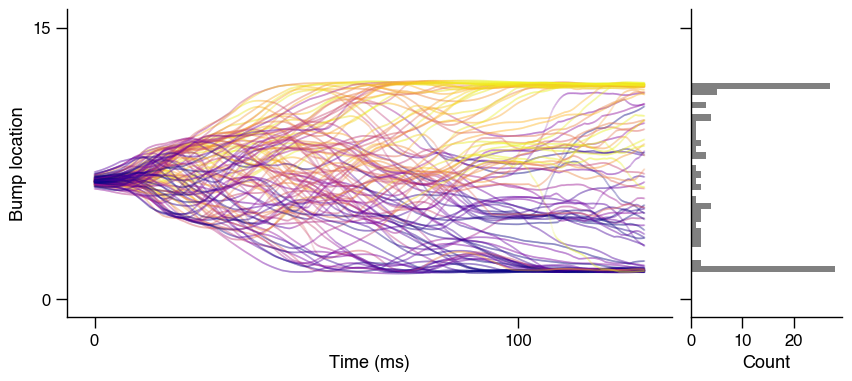

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


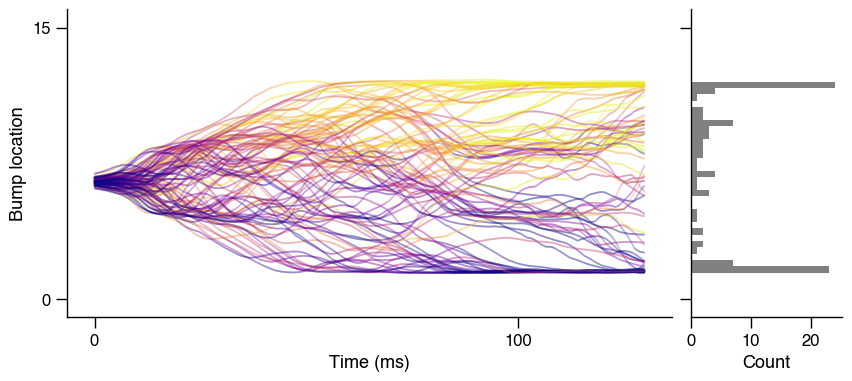

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


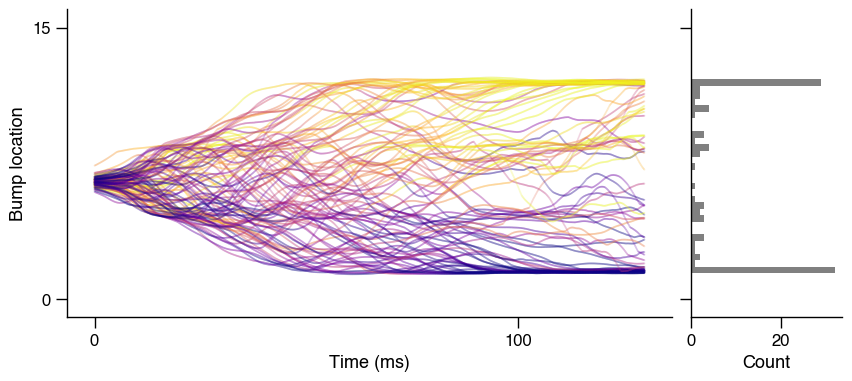

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


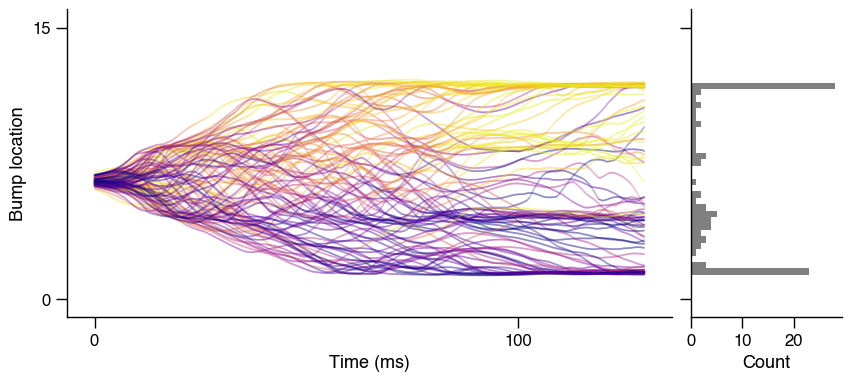

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


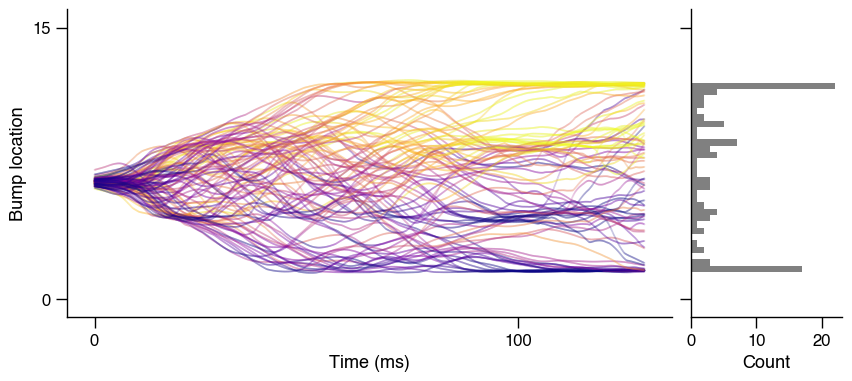

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


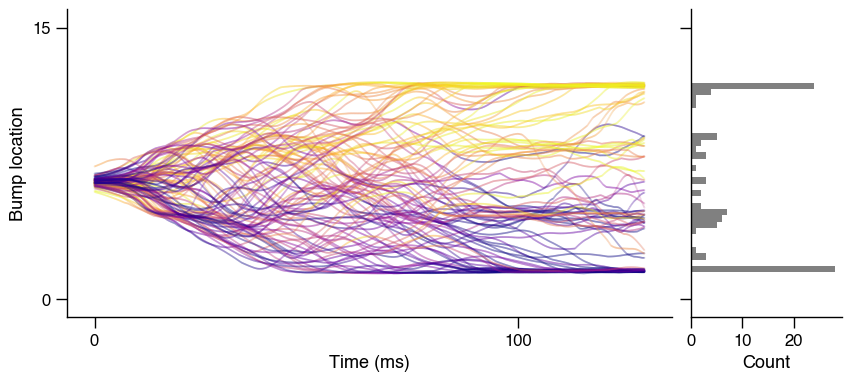

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


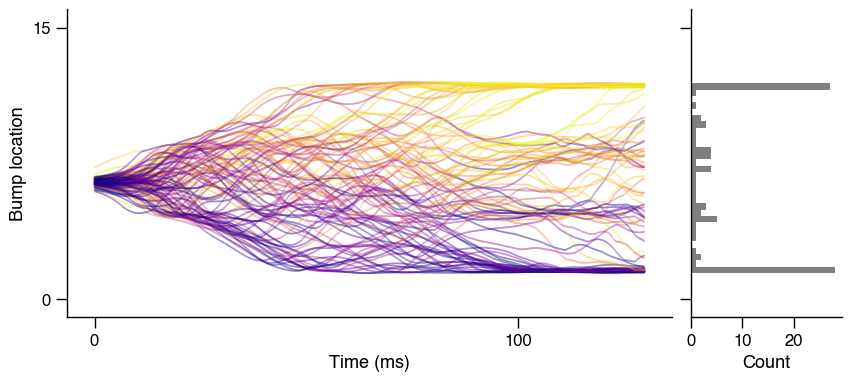

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


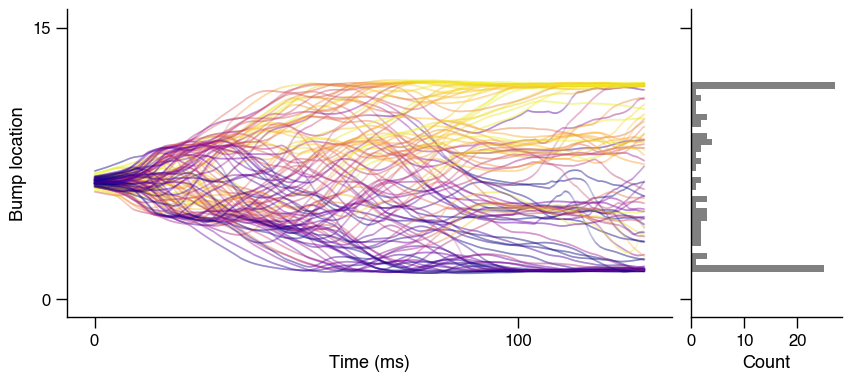

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


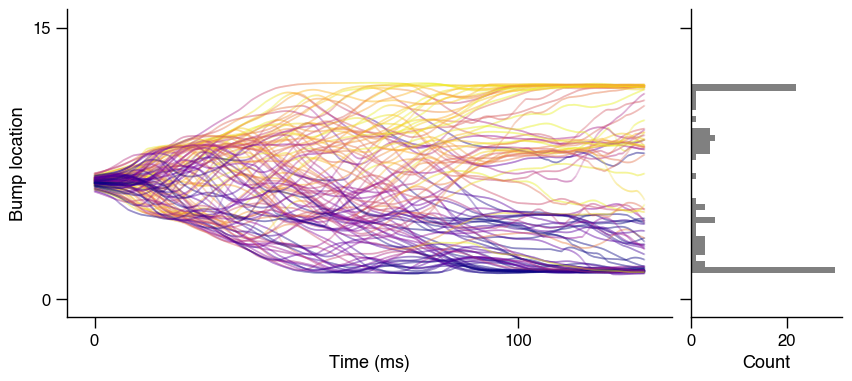

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


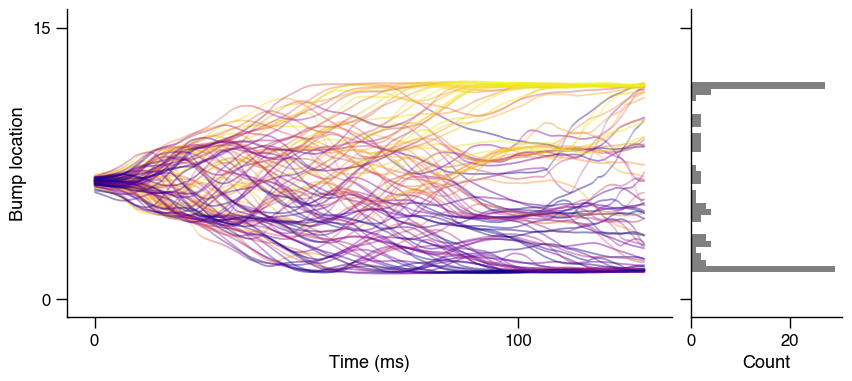

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


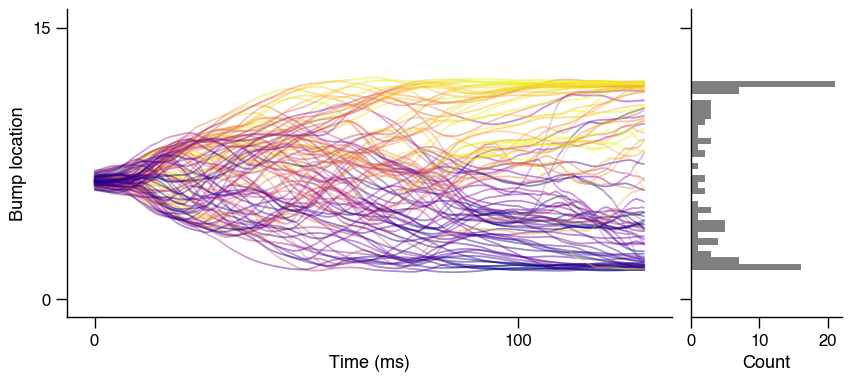

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


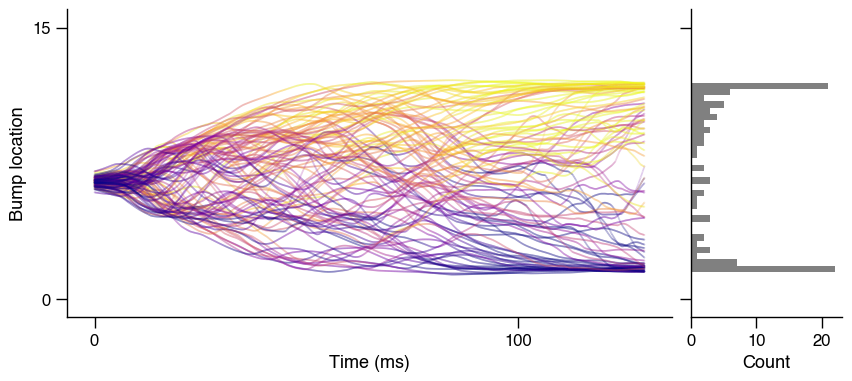

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


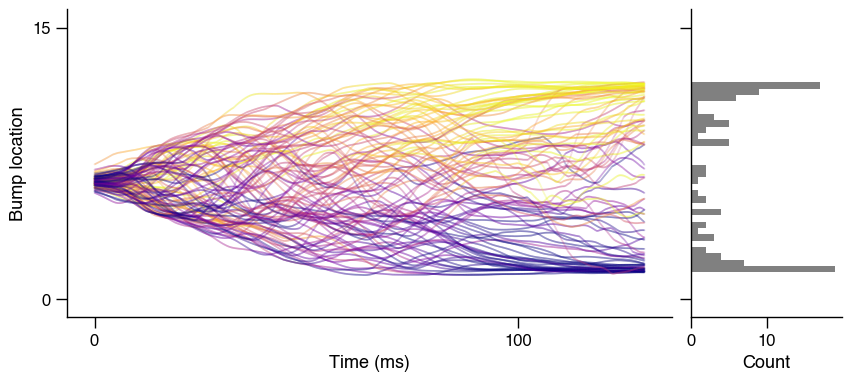

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


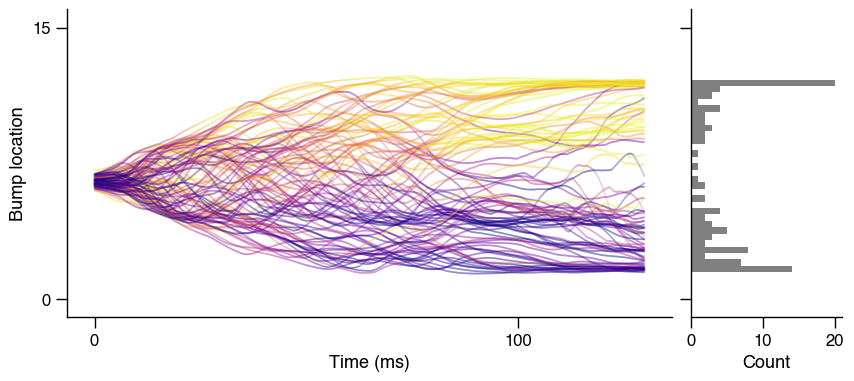

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


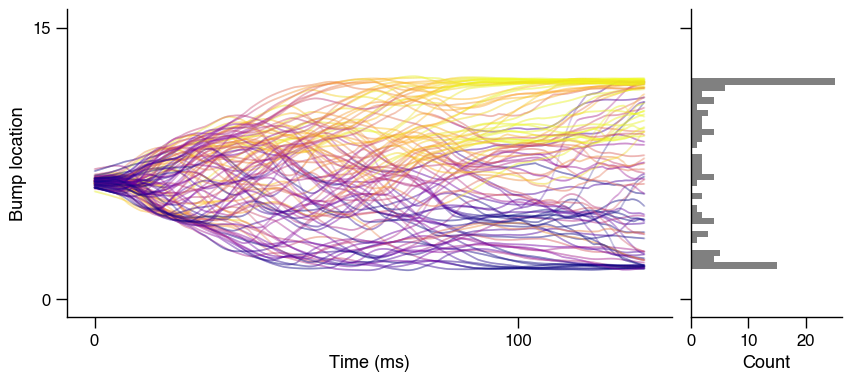

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


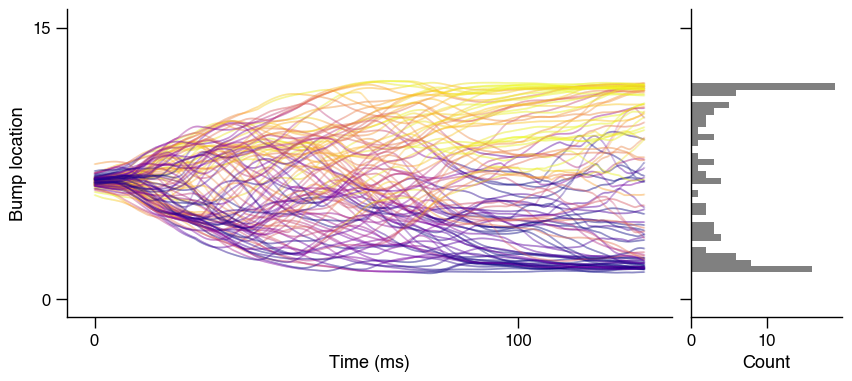

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


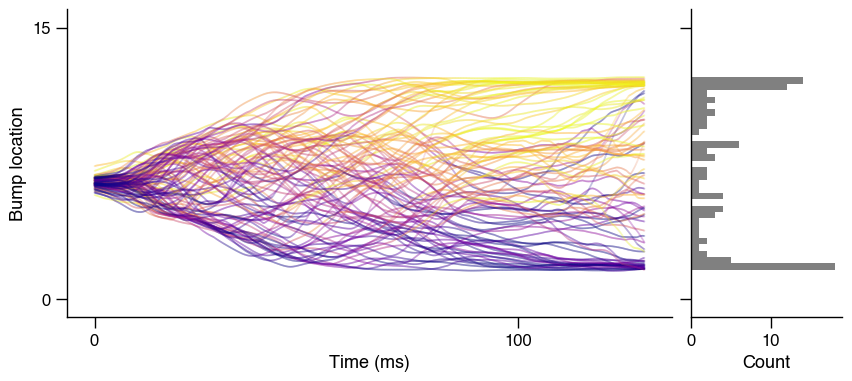

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


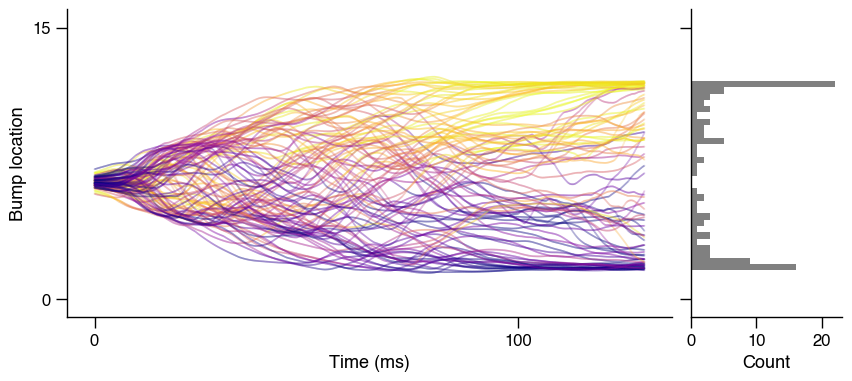

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


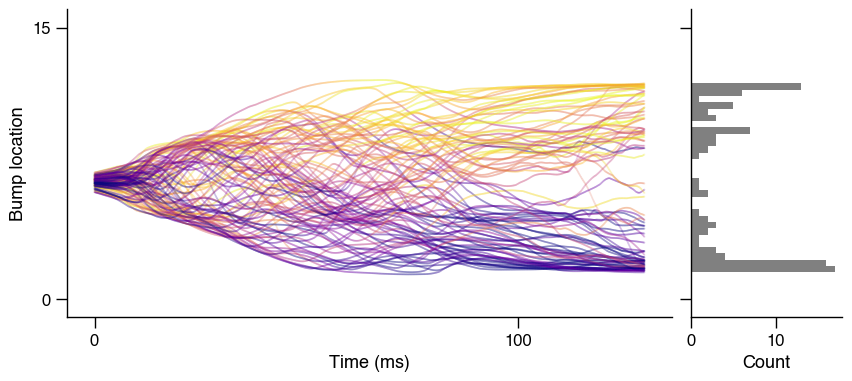

(15, 100, 1299)
(100, 1299)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


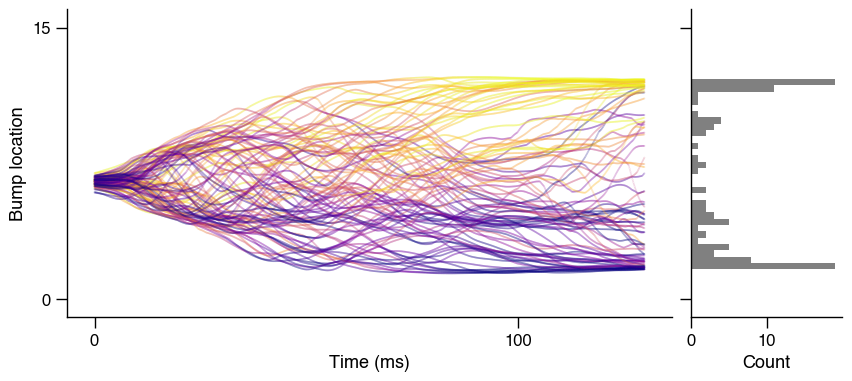

In [15]:
for dp in DATA_PATHS:
    for i in range(10):
        last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy')
        make_stability_plot(last_100_r, all_int_values)

In [14]:
train_range = slice(280, 300)
test_range = slice(300, 400)
readout_neuron_range = slice(0, 15)

stacked_activities_train = all_r[train_range, 200:, readout_neuron_range]
y_train = all_int_values_raw[train_range, :]
stacked_activities_test = all_r[test_range, 200:, readout_neuron_range]
y_test = all_int_values_raw[test_range, :]

scores = []

for i in range(100):
    train_acts = np.random.randint(0, 20, size=1000)
    train_steps = np.random.randint(0, 800, size=1000)
    test_acts = np.arange(100)
    test_steps = np.random.randint(0, 800, size=100)
    
    X_train = stacked_activities_train[train_acts, train_steps, :]
    Y_train = y_train[train_acts, train_steps]
    
    X_test = stacked_activities_test[test_acts, test_steps, :]
    Y_test = y_test[test_acts, test_steps]
    
    reg = LinearRegression().fit(X_train, Y_train)
    score = reg.score(X_test, Y_test)
    scores.append(score)

print(scores)
print(np.mean(scores))

[0.8294490241141705, 0.7799075073895065, 0.8065507715471801, 0.7995012091778937, 0.7718079181919435, 0.7979817926319519, 0.8217220006645763, 0.8237794520817039, 0.7407351173532505, 0.7866939694809152, 0.7800298622048276, 0.8238667508127181, 0.8113799789562811, 0.8068051371776234, 0.7504274228665738, 0.7128029728336731, 0.7687751865199597, 0.7721502818312059, 0.8208244994154006, 0.76115503055712, 0.7727774171688486, 0.7462906086326693, 0.7422339530138817, 0.785580574332585, 0.8170935280583882, 0.7614467353652004, 0.7002494347238165, 0.822800729805128, 0.7867571759058664, 0.8182122231166492, 0.7553645788958696, 0.7500303722147486, 0.7256005286211424, 0.7979757868557302, 0.7820012720392759, 0.7781199942610291, 0.763922965024136, 0.8164821723889873, 0.7857415579824919, 0.7470572181801075, 0.7556943484049242, 0.7690609727877531, 0.7593571367474083, 0.8060003450826055, 0.8432994616931071, 0.8491116888948792, 0.7007135852173884, 0.7867499088154168, 0.8051991009922148, 0.8135470993396858, 0.83

Axes(0.125,0.11;0.775x0.77)


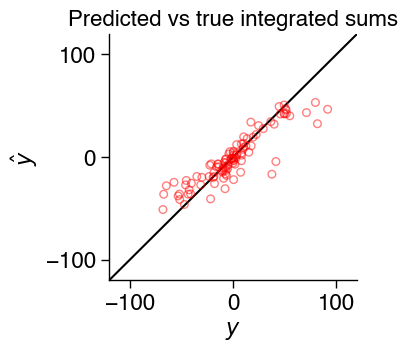

In [15]:
scale = 0.8
fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 4 * scale))

axs.plot([-120, 120], [-120, 120], color='black', zorder=0)
axs.scatter(Y_test, reg.predict(X_test), s=30, zorder=1, facecolor='none', edgecolor='red', alpha=0.5)
axs.set_xlim(-120, 120)
axs.set_ylim(-120, 120)
axs.set_xticks([-100, 0, 100])
axs.set_yticks([-100, 0, 100])

format_plot(axs)

axs.set_xlabel(r'$y$', fontsize=16)
axs.set_ylabel(r'$\hat{y}$', fontsize=16)
axs.set_title('Predicted vs true integrated sums', fontsize=16)
axs.tick_params(axis='both', length=6, labelsize=16)

In [ ]:
train_range = slice(280, 300)
test_range = slice(300, 400)
readout_neuron_range = slice(0, 15)

stacked_activities_train = all_r[train_range, 200:, readout_neuron_range]
y_train = all_int_values_raw[train_range, :]
stacked_activities_test = all_r[test_range, 200:, readout_neuron_range]
y_test = all_int_values_raw[test_range, :]

scores = []

train_acts = np.random.randint(0, 20, size=1000)
train_steps = np.random.randint(0, 800, size=1000)
test_acts = np.arange(100)
test_steps = np.random.randint(0, 800, size=100)

X_train = stacked_activities_train[train_acts, train_steps, :]
Y_train = y_train[train_acts, train_steps]

X_test = stacked_activities_test[test_acts, test_steps, :]
Y_test = y_test[test_acts, test_steps]

reg = LinearRegression().fit(X_train, Y_train)
score = reg.score(X_test, Y_test)
scores.append(score)

print(scores)
print(np.mean(scores))

In [ ]:
scale = 0.8
fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 4 * scale))

axs.plot([-120, 120], [-120, 120], color='black', zorder=0)
axs.scatter(Y_test, reg.predict(X_test), s=30, zorder=1, facecolor='none', edgecolor='red', alpha=0.5)
axs.set_xlim(-120, 120)
axs.set_ylim(-120, 120)
axs.set_xlabel(r'$y$', fontsize=16)
axs.set_ylabel(r'$\hat{y}$', fontsize=16)
axs.set_title('Predicted vs true integrated sums', fontsize=16)
axs.tick_params(axis='both', length=6, labelsize=16)